<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB1/Experiencia_3_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiencia 3 - Optimización de mezclas de hormigón para obra civil

##0. Consideraciones y configuracion del entorno

Estas son las consideraciones iniciales que debemos tener en cuenta a la hora de entrenar el modelo y buscar soluciones a nuestra problematica.

Objetivos:
- Reducir costo de mezclas de hormigón
- Cumplir con los requisitos mínimos de MPa.
- Compensar cemento con agregados.

Información previa:
- El cemento tiene una relacion lineal con el MPa
- Los agregados tienen una relacion no lineal con el MPa

Riesgos del *target*:
- Subestimar la resistencia es un costo extra innecesario
- Sobreestimar la resistencia es un error estructural fatal

In [ ]:
# @title #####Configuracion del entorno

# Importaciones
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Modulos no instalados
!pip install lazypredict
from lazypredict.Supervised import LazyRegressor

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Entorno configurado.")

Entorno configurado.


##1. Carga y exploracion inicial

###1.1 Carga de datos

In [ ]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Version Online
if not os.path.exists("datos_ccs.zip"):
  !wget https://github.com/AxelSkrauba/applied-ai-engineering/raw/main/datasets/ccs/datos_ccs.zip

In [ ]:
if not os.path.exists("datos_ccs.csv"):
    !unzip datos_ccs.zip
df_ccs = pd.read_csv("datos_ccs.csv")

###1.2 Inspeccion inicial y calidad de datos

In [ ]:
print(f"Dimensiones: {df_ccs.shape}")
print(f"\nTipos de datos:\n{df_ccs.dtypes}")
print(f"\nFaltantes: {df_ccs.isnull().sum().sum()} (ninguno)")
print(f"\nPrimeras filas:")
df_ccs

Dimensiones: (1030, 9)

Tipos de datos:
cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object

Faltantes: 0 (ninguno)

Primeras filas:


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [ ]:
print("Detectando valores negativos:")
negative_values_found = False
for column in df_ccs.columns:
    if (df_ccs[column] < 0).any():
        negative_values_found = True
        print(f"  - La columna '{column}' contiene valores negativos.")
        print(df_ccs[df_ccs[column] < 0][column])

if not negative_values_found:
    print("  - No se encontraron valores negativos en el dataset.")

Detectando valores negativos:
  - No se encontraron valores negativos en el dataset.


##2. Análisis exploratorio orientado al problema

In [ ]:
# @title Tabla de media, desviación estándar y coeficiente de variación (CV)
columnas_numericas = df_ccs.select_dtypes(include=['number']).columns

# Calcular la media y la desviaci3n est1ndar para cada columna num1rica
valores_media = df_ccs[columnas_numericas].mean()
valores_desviacion = df_ccs[columnas_numericas].std()

# CV = Desviaci3n Est1ndar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados
medidas_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
})

# Obtener el orden de las columnas basado en CV (excluyendo csMPa)
columnas_ordenadas_cv = cv.drop('csMPa').sort_values(ascending=True).index.tolist()
columns_order = columnas_ordenadas_cv + ['csMPa']

# Transponer y reordenar
medidas_df = medidas_df.T[columns_order]

# Mostrar el DataFrame
display(medidas_df)

,coarseaggregate,fineaggregate,water,cement,superplasticizer,slag,flyash,age,csMPa
Media,972.918932,773.580485,181.567282,281.167864,6.204660,73.895825,54.188350,45.662136,35.817961
Desviación Estándar,77.753954,80.175980,21.354219,104.506364,5.973841,86.279342,63.997004,63.169912,16.705742
Coeficiente de Variación,0.079918,0.103643,0.117610,0.371687,0.962799,1.167581,1.181010,1.383420,0.466407


- Poca variacion en el agua y agregados (base constante).
- Variacion moderada en cemento.
- Gran variacion en aditivos y edad.

In [ ]:
# @title Tabla de media, mediana, Dif. Absoluta, Dif. Porcentual de cada variable.
# Calcular la media y la mediana para cada columna numérica
valores_mediana = df_ccs[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - valores_mediana).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': valores_mediana,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
})

columnas_ordenadas_dp = diferencia_porcentual.drop('csMPa').sort_values(ascending=True).index.tolist()
columns_order = columnas_ordenadas_dp + ['csMPa']

diferencia_df = diferencia_df.T[columns_order]

display(diferencia_df)

,coarseaggregate,fineaggregate,water,cement,superplasticizer,age,slag,flyash,csMPa
Media,972.918932,773.580485,181.567282,281.167864,6.204660,45.662136,73.895825,54.18835,35.817961
Mediana,968.000000,779.500000,185.000000,272.900000,6.400000,28.000000,22.000000,0.00000,34.445000
Diferencia Absoluta (Media - Mediana),4.918932,5.919515,3.432718,8.267864,0.195340,17.662136,51.895825,54.18835,1.372961
Diferencia Porcentual (%),0.505585,0.765210,1.890604,2.940544,3.148276,38.680048,70.228359,100.00000,3.833164


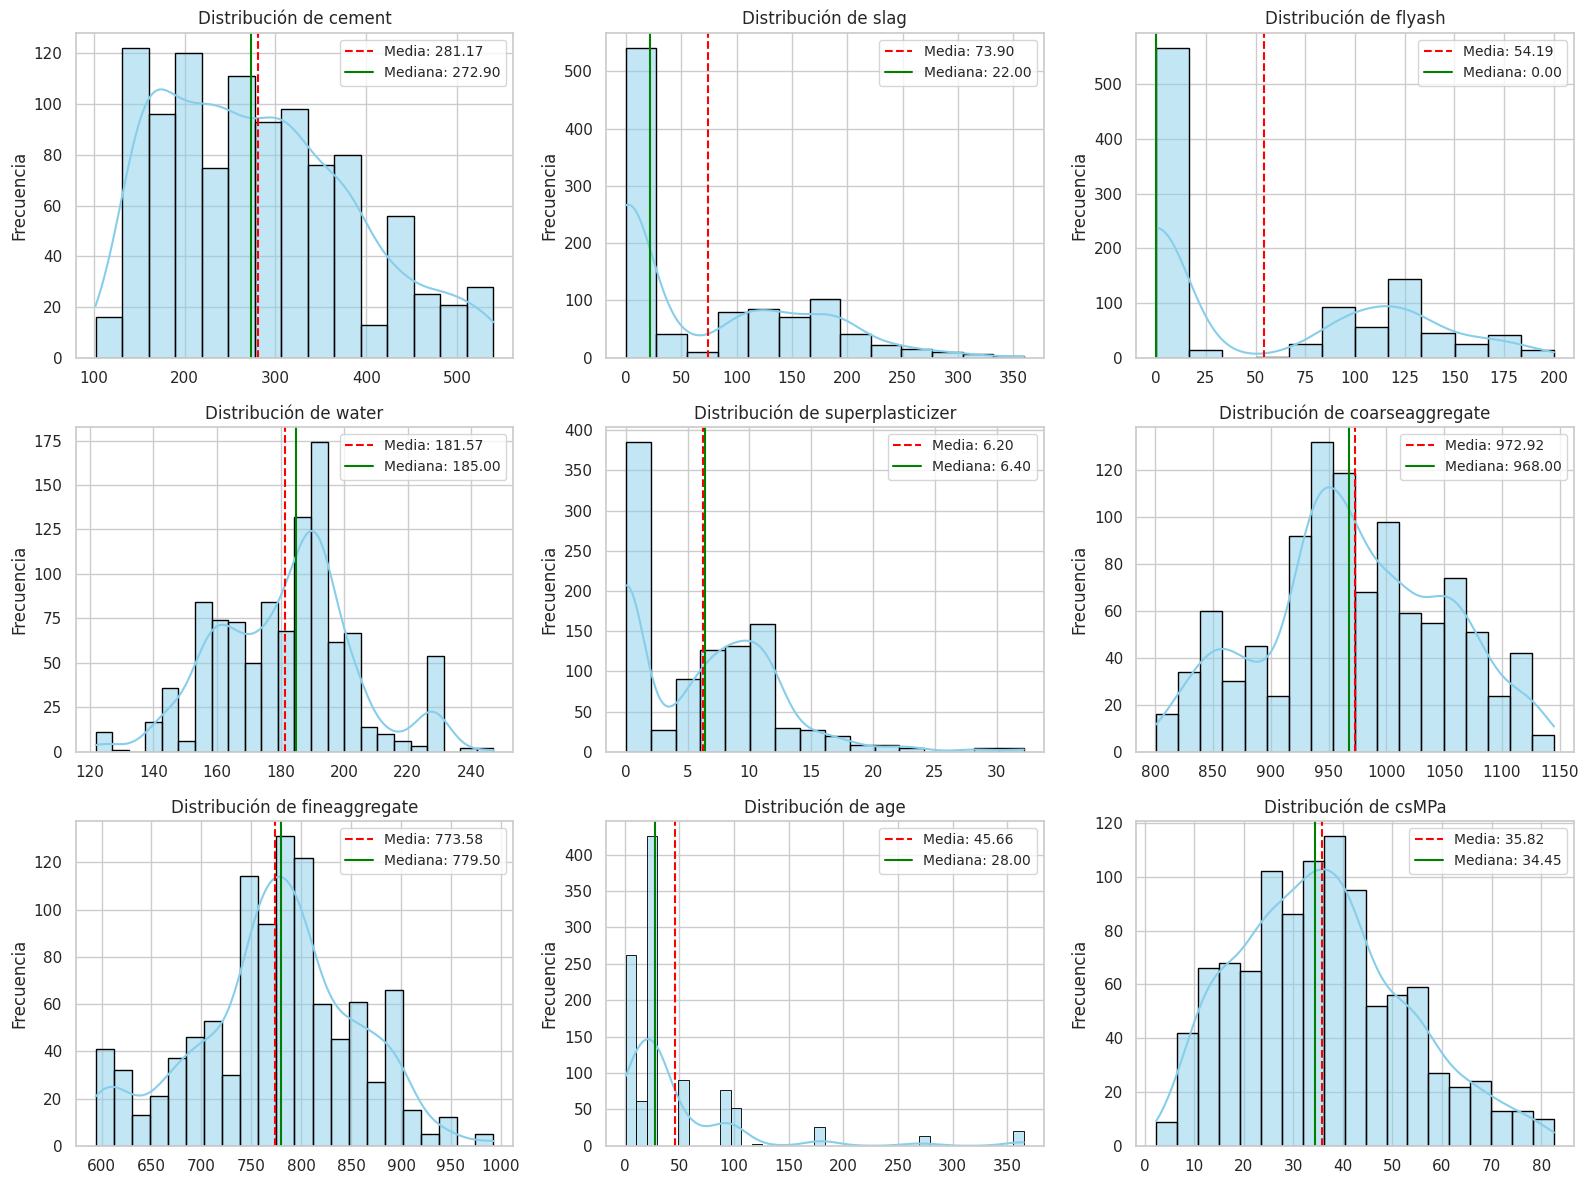

In [ ]:
# @title Histogramas de distribución para todas las variables
# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Definir el número de filas y columnas para la cuadrícula
n_cols = 3
n_rows = (len(df_ccs.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(df_ccs.columns):
    sns.histplot(df_ccs[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')

    # Calcular media y mediana
    mean_val = df_ccs[col].mean()
    median_val = df_ccs[col].median()

    # Agregar líneas de referencia
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize='small')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

  - Distribucion simetrica en `coarseaggregate`, `fineaggregate	` y `water`.
- Distribucion ligeramente sesgada (hacia la derecha) en `cement` y `csMPa`.
- Distribucion altamente sesgada (hacia la derecha) en `age`.
- Distribucion bimodal en `slag`, `flyash` y `superplasticizer`.



Distribuciones

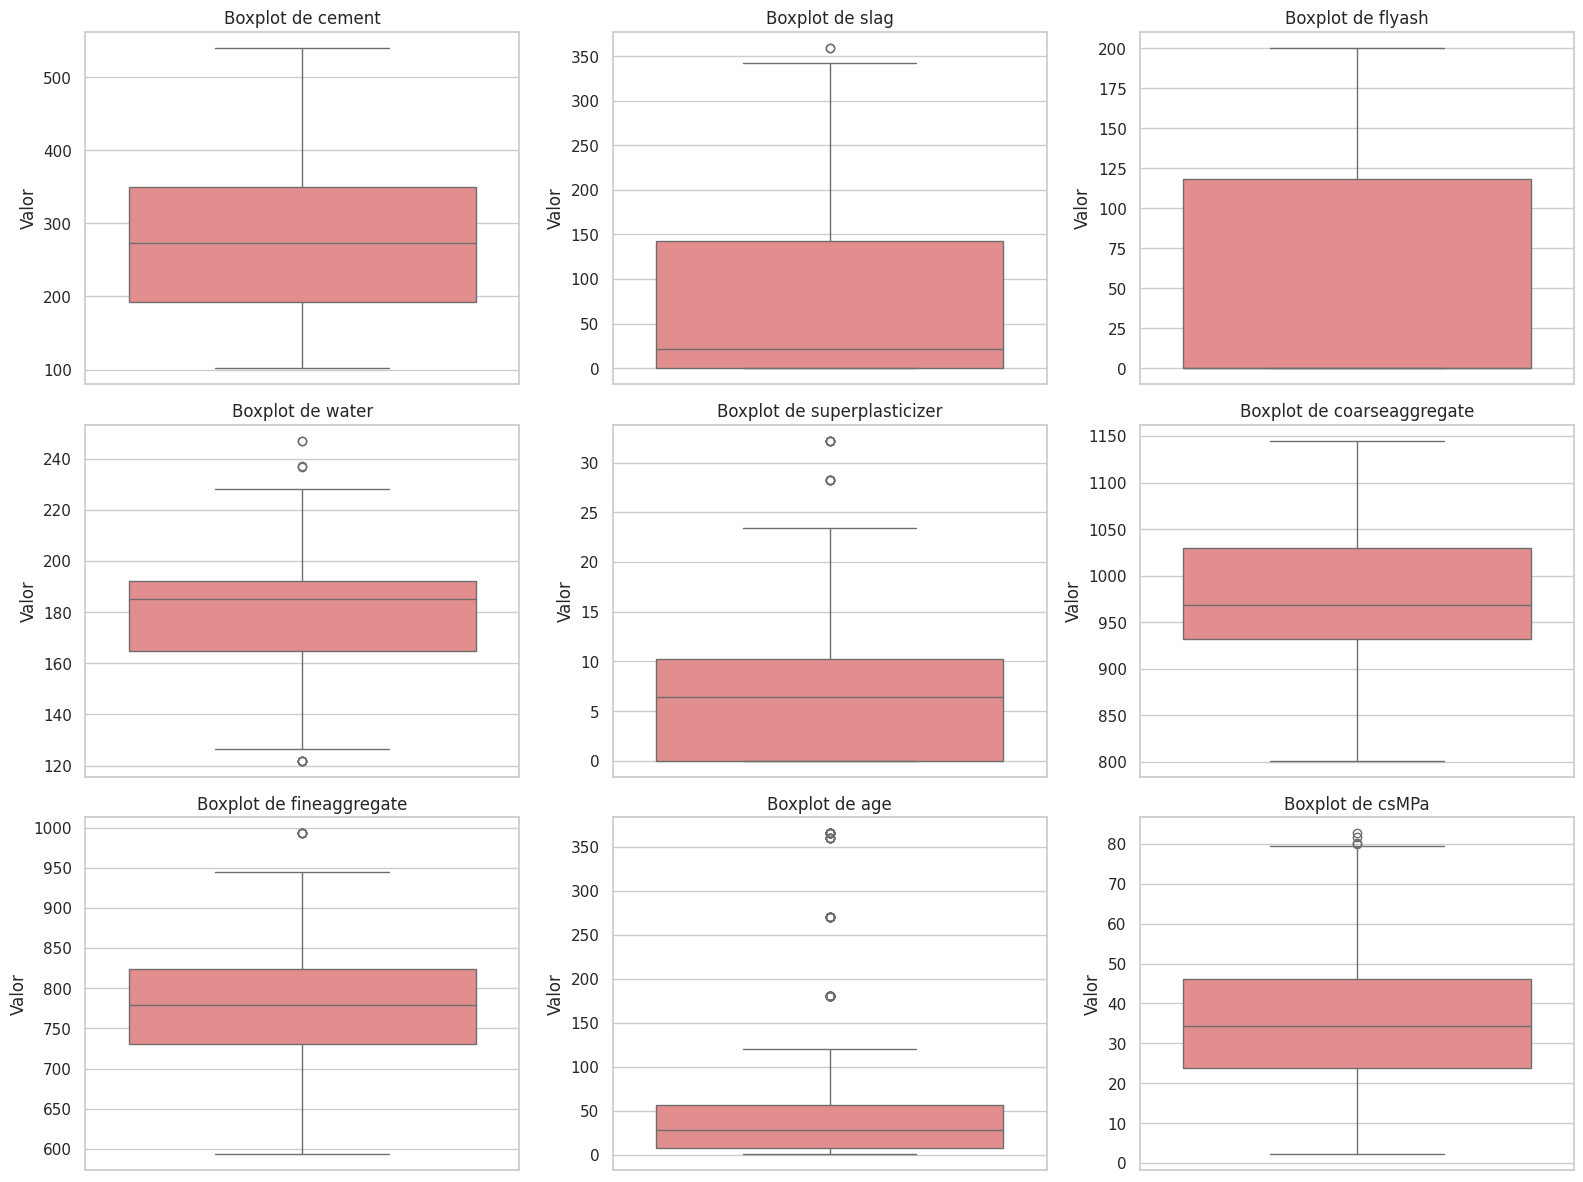

In [ ]:
# @title Diagramas de caja (Boxplots) para todas las variables
# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Definir el número de filas y columnas para la cuadrícula
n_cols = 3
n_rows = (len(df_ccs.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(df_ccs.columns):
    sns.boxplot(y=df_ccs[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_ylabel('Valor')
    axes[i].set_xlabel('')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Análisis de outliers para superplasticizer
Q1_sp = df_ccs['superplasticizer'].quantile(0.25)
Q3_sp = df_ccs['superplasticizer'].quantile(0.75)
IQR_sp = Q3_sp - Q1_sp

inferior_sp = Q1_sp - 1.5 * IQR_sp
superior_sp = Q3_sp + 1.5 * IQR_sp

outliers_sp = df_ccs[df_ccs['superplasticizer'] > superior_sp]

print(f"--- Estadísticas de Superplasticizer ---")
print(f"Límite superior detectado: {superior_sp:.2f}")
print(f"Cantidad de valores extremos: {len(outliers_sp)}")
print(f"Valor máximo en el dataset: {df_ccs['superplasticizer'].max()}")

print("\nTop de registros con valores extremos:")
display(outliers_sp.sort_values(by='superplasticizer', ascending=False).head(10))

--- Estadísticas de Superplasticizer ---
Límite superior detectado: 25.50
Cantidad de valores extremos: 10
Valor máximo en el dataset: 32.2

Top de registros con valores extremos:


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
76,469.0,117.2,0.0,137.8,32.2,852.1,840.5,3,40.2
99,469.0,117.2,0.0,137.8,32.2,852.1,840.5,7,54.9
168,469.0,117.2,0.0,137.8,32.2,852.1,840.5,91,70.7
122,469.0,117.2,0.0,137.8,32.2,852.1,840.5,28,66.9
145,469.0,117.2,0.0,137.8,32.2,852.1,840.5,56,69.3
79,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3,41.3
125,531.3,0.0,0.0,141.8,28.2,852.1,893.7,28,56.4
102,531.3,0.0,0.0,141.8,28.2,852.1,893.7,7,46.9
148,531.3,0.0,0.0,141.8,28.2,852.1,893.7,56,58.8
171,531.3,0.0,0.0,141.8,28.2,852.1,893.7,91,59.2


In [ ]:
# @title Prototipado Rápido

# 1. Preparación de datos para entrenamiento
X = df_ccs.drop(columns=['csMPa'])
y = df_ccs['csMPa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# 2. Inicializar y entrenar LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# 3. Mostrar resultados (Todos los modelos)
print("Comparativa completa de modelos evaluados:")
pd.set_option('display.max_rows', None)  # Asegurar que se muestren todos en el notebook
display(models)

Comparativa completa de modelos evaluados:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
XGBRegressor,0.914312,0.917656,4.606305,0.869411
HistGradientBoostingRegressor,0.913975,0.917332,4.615362,0.480505
LGBMRegressor,0.909000,0.912551,4.746958,0.146225
ExtraTreesRegressor,0.888543,0.892893,5.253479,0.322039
RandomForestRegressor,0.879465,0.884169,5.463242,1.064325
GradientBoostingRegressor,0.878133,0.882889,5.493350,0.264829
BaggingRegressor,0.854371,0.860054,6.005076,0.076299
DecisionTreeRegressor,0.828040,0.834750,6.525414,0.017049
ExtraTreeRegressor,0.799692,0.807509,7.042768,0.013460


Se puede observar un claro exito en los modelos **no lineales** como arboles de decision y vectores gradientes.

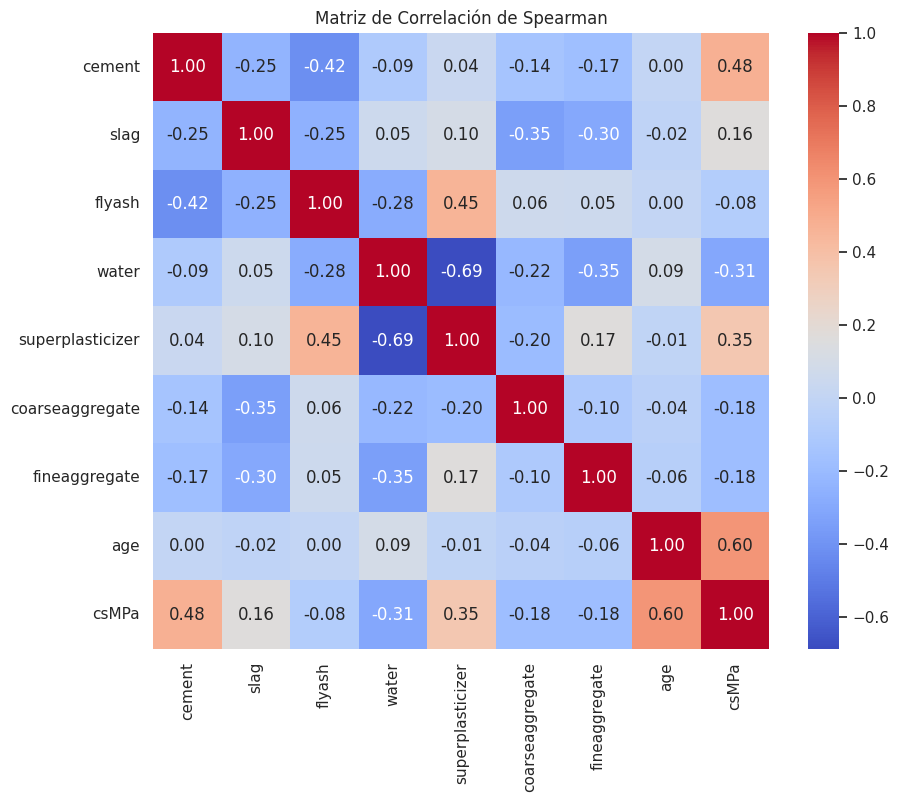

In [ ]:
# @title Matriz de Correlación de Spearman
plt.figure(figsize=(10, 8))
corr_spearman = df_ccs.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlación de Spearman')
plt.show()

Relaciones lineales
- El csMPa tiene buenas correlaciones con el cemento, el agua y la edad, lo cual tiene sentido segun la informacion recopilada.
- El superplastificante parece tener mucha correlacion con el agua (material suplementario del agua), ademas de influir mucho en nuestro target.
- La escoria (*slag*) y las cenizas volantes (*fly ash*) tienen correlacion con el cemento (materiales suplementarios del cemento).

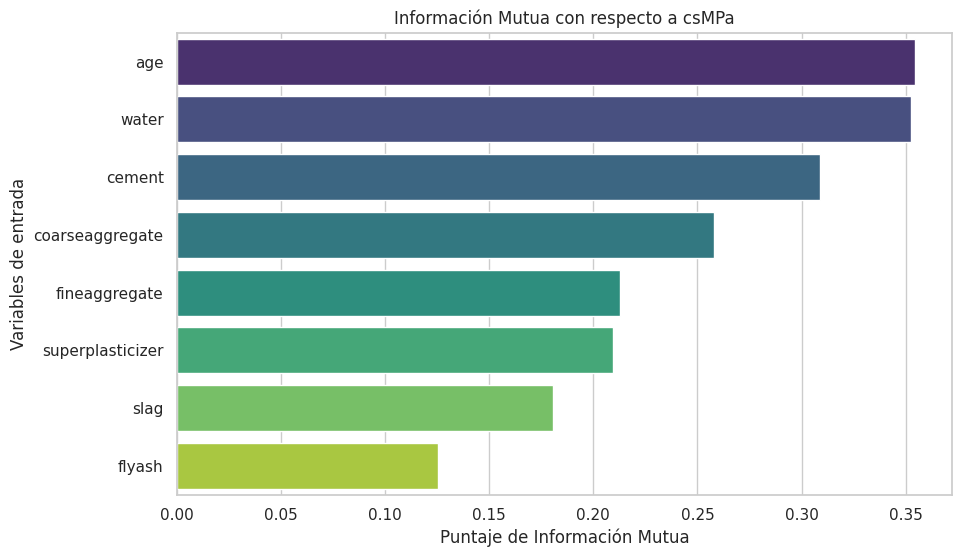

In [ ]:
from sklearn.feature_selection import mutual_info_regression

# Preparar datos
X = df_ccs.drop('csMPa', axis=1)
y = df_ccs['csMPa']

# Calcular información mutua
mi_scores = mutual_info_regression(X, y, random_state=SEED)
mi_series = pd.Series(mi_scores, name="Información Mutua", index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette='viridis', legend=False)
plt.title('Información Mutua con respecto a csMPa')
plt.xlabel('Puntaje de Información Mutua')
plt.ylabel('Variables de entrada')
plt.show()

Informacion mutua
- Otra vez los mas influyentes son la edad, el cemento y el agua.
- El superplastificante bajo un poco, pero se mantiene en la ecuacion.

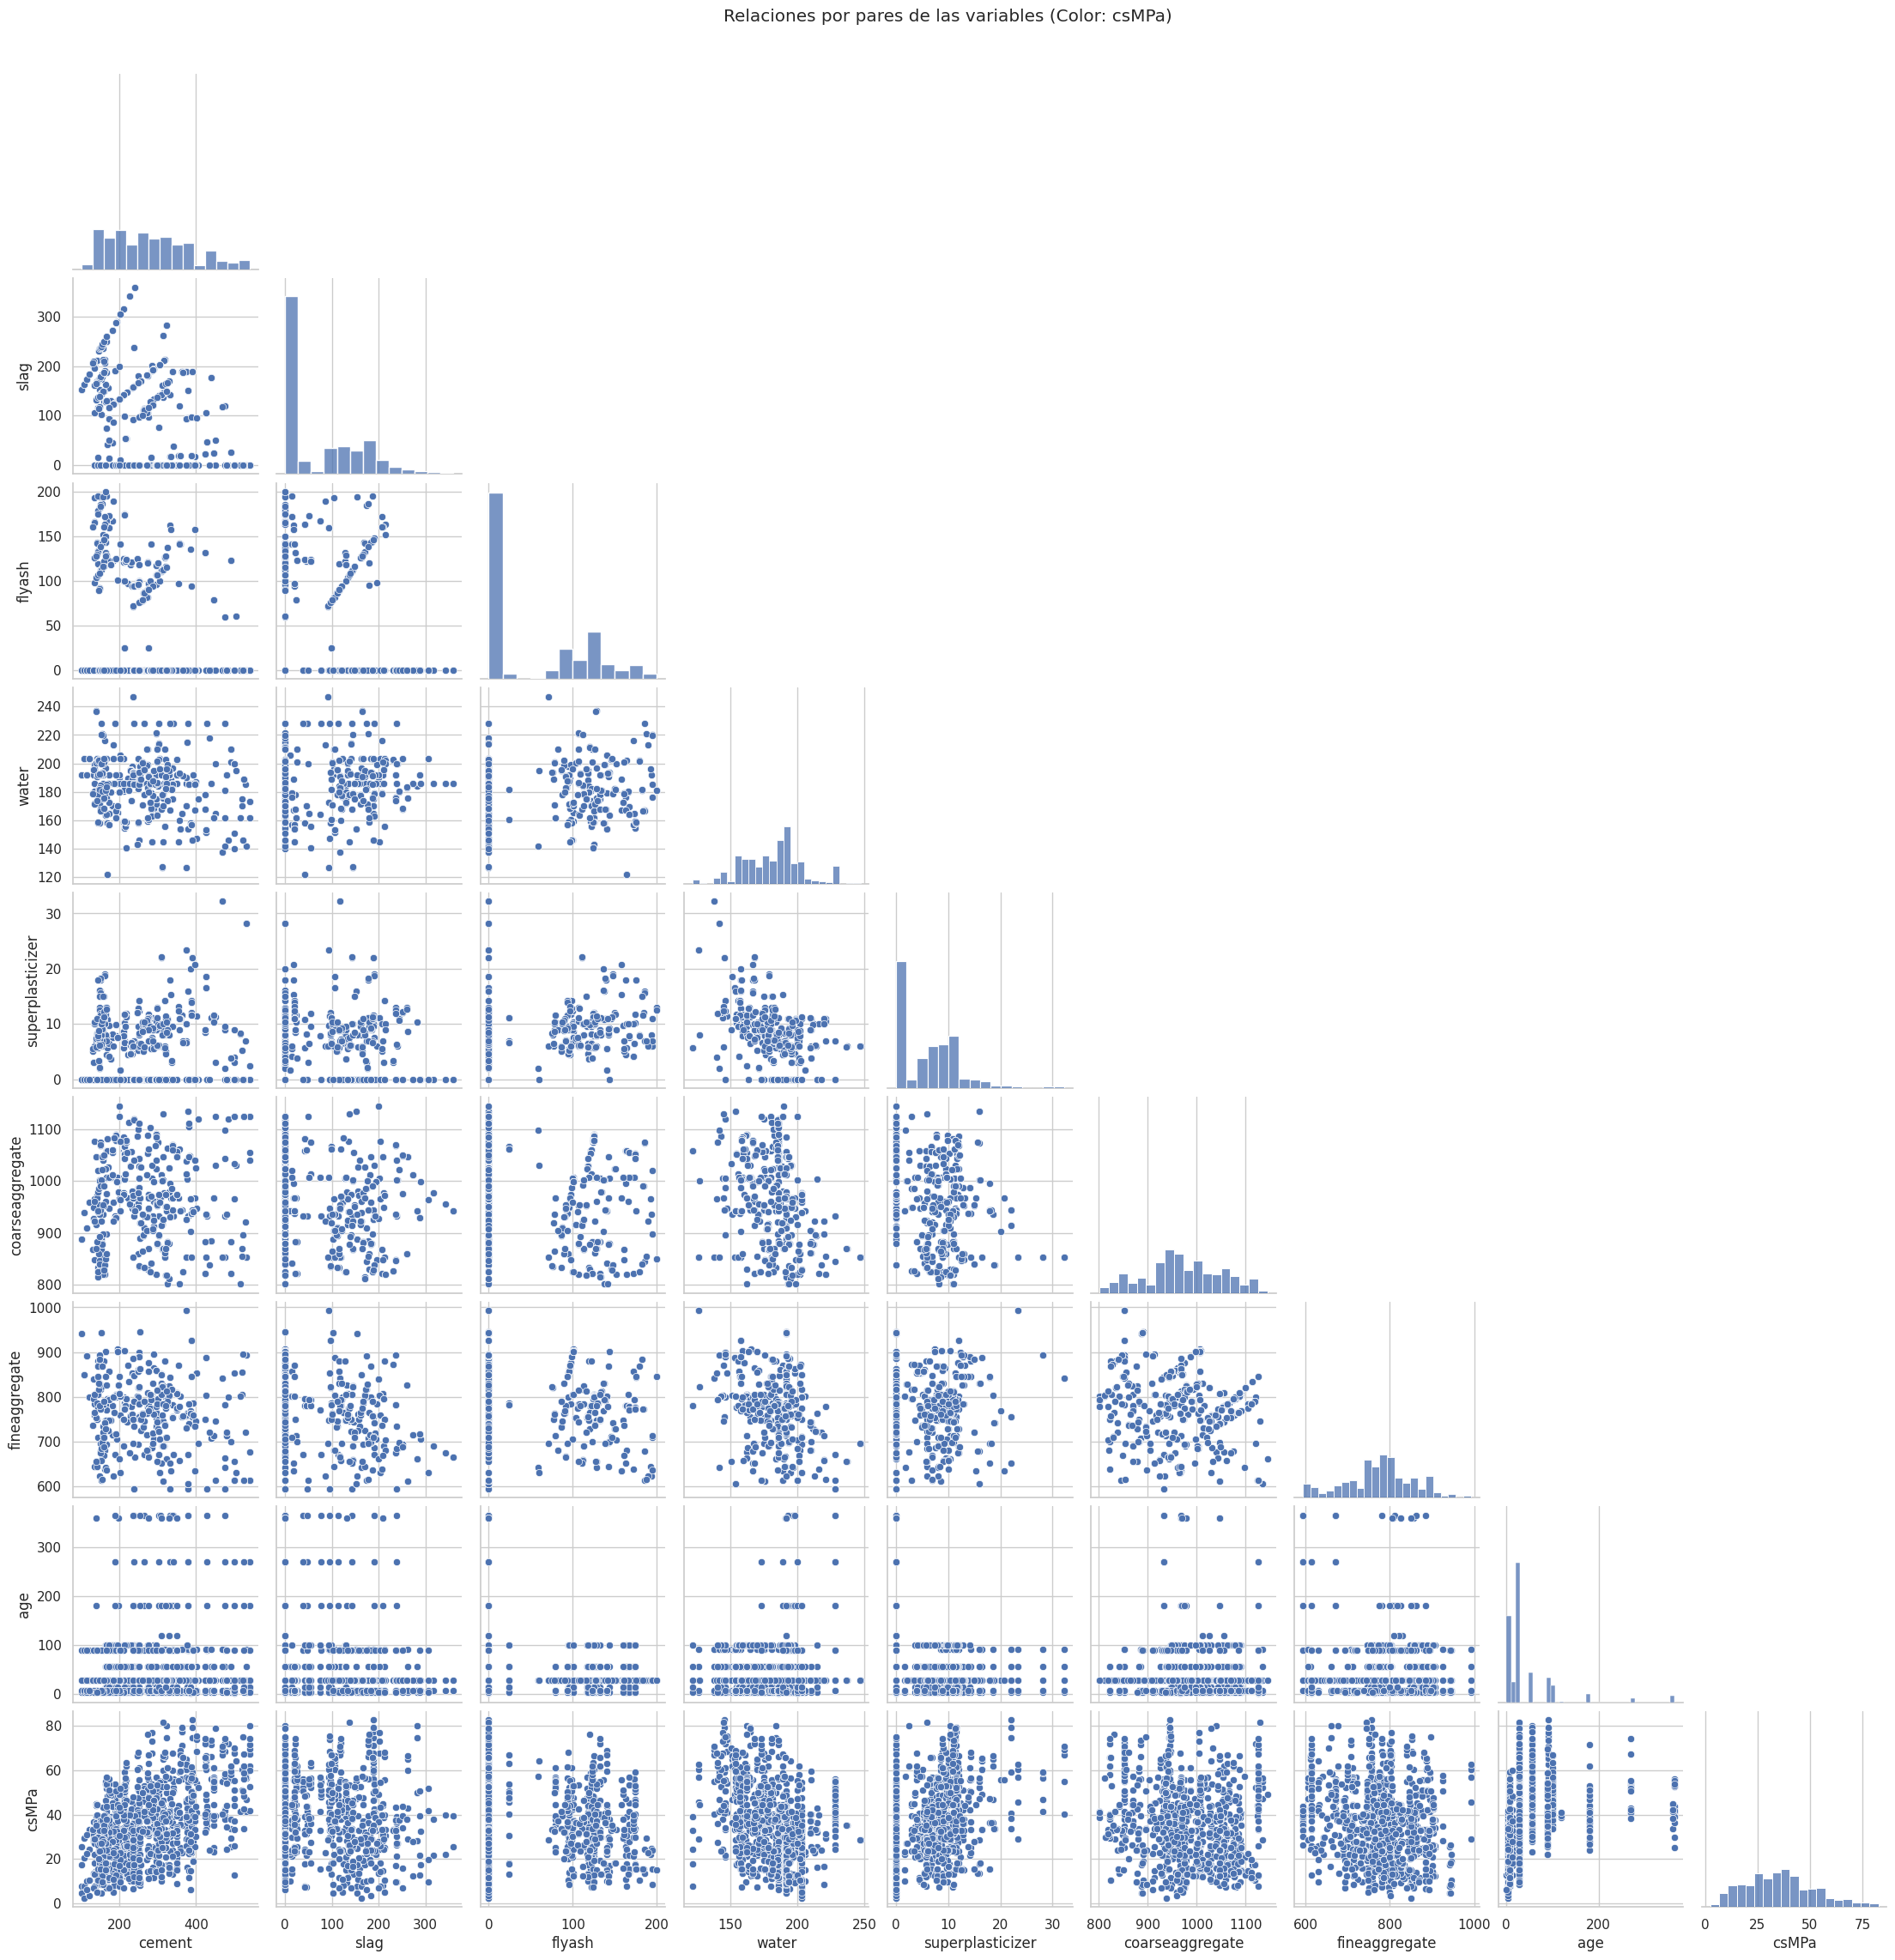

In [ ]:
# Pairplot de las variables con el target como color
sns.pairplot(df_ccs, corner=True)
plt.suptitle('Relaciones por pares de las variables (Color: csMPa)', y=1.02)
plt.show()

In [ ]:
# Crear la nueva variable de relación líquidos/sólidos aglutinantes
# Relación (Agua + Superplastificante) / (Cemento + Fly Ash + Slag)
df_ccs['binder_liquid_ratio'] = ((df_ccs['cement'] + df_ccs['flyash'] + df_ccs['slag']) / (df_ccs['water'] + df_ccs['superplasticizer']))

# Mostrar las primeras filas y la correlación con la resistencia
print("Nuevas dimensiones del dataset:", df_ccs.shape)
display(df_ccs[['water', 'superplasticizer', 'cement', 'flyash', 'slag', 'binder_liquid_ratio', 'csMPa']].head())

# Calcular correlación de Spearman para evaluar su impacto
corr_new = df_ccs[['binder_liquid_ratio', 'csMPa']].corr(method='spearman').iloc[0, 1]
print(f"\nCorrelación de Spearman entre 'binder_liquid_ratio' y 'csMPa': {corr_new:.4f}")

Nuevas dimensiones del dataset: (1030, 10)


,water,superplasticizer,cement,flyash,slag,binder_liquid_ratio,csMPa
0,162.0,2.5,540.0,0.0,0.0,3.282675,79.99
1,162.0,2.5,540.0,0.0,0.0,3.282675,61.89
2,228.0,0.0,332.5,0.0,142.5,2.083333,40.27
3,228.0,0.0,332.5,0.0,142.5,2.083333,41.05
4,192.0,0.0,198.6,0.0,132.4,1.723958,44.30



Correlación de Spearman entre 'binder_liquid_ratio' y 'csMPa': 0.6036


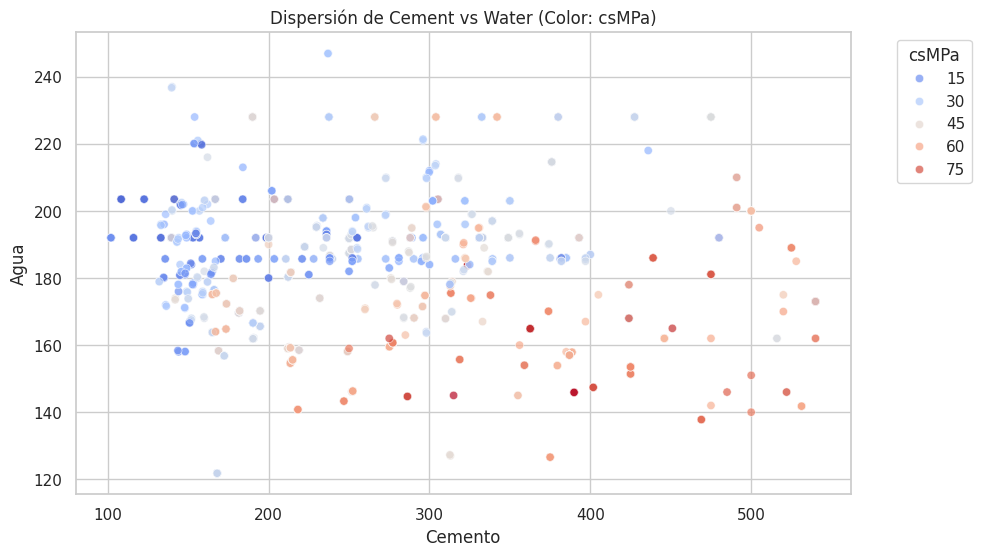

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='cement', y='water', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Cement vs Water (Color: csMPa)')
plt.xlabel('Cemento')
plt.ylabel('Agua')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

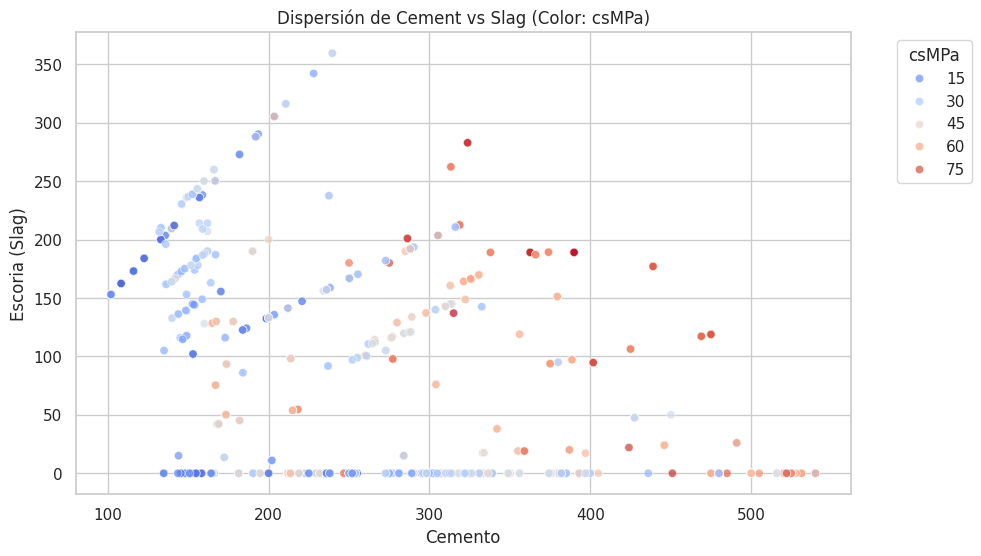

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='cement', y='slag', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Cement vs Slag (Color: csMPa)')
plt.xlabel('Cemento')
plt.ylabel('Escoria (Slag)')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

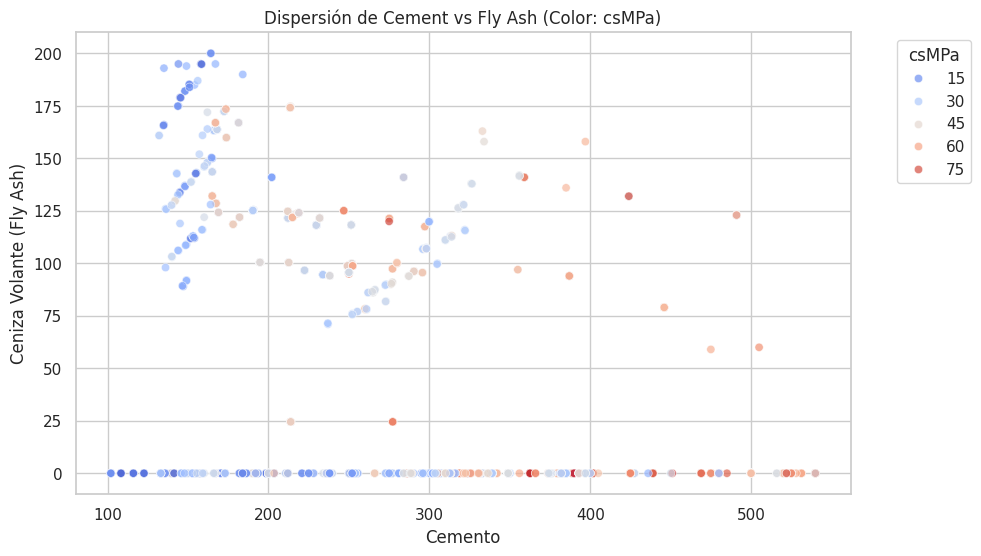

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='cement', y='flyash', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Cement vs Fly Ash (Color: csMPa)')
plt.xlabel('Cemento')
plt.ylabel('Ceniza Volante (Fly Ash)')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

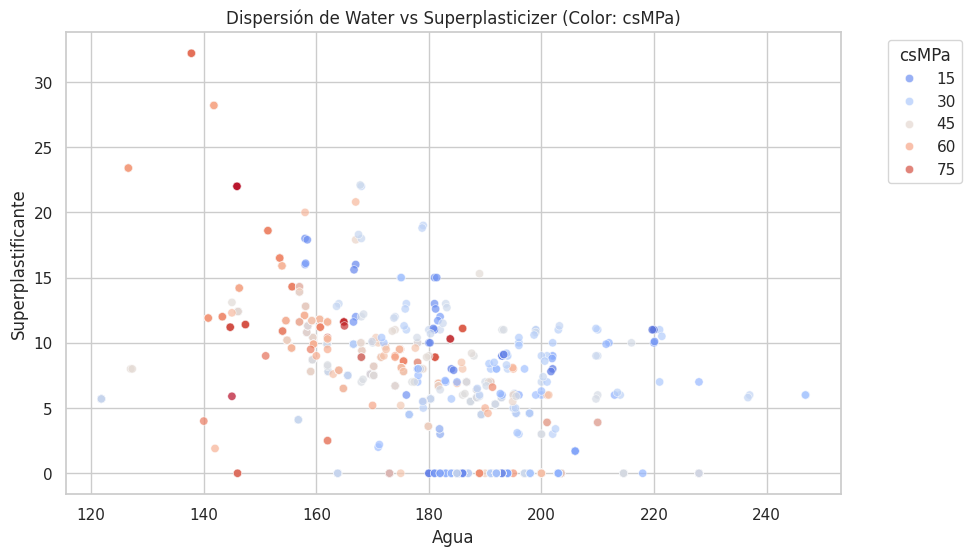

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ccs, x='water', y='superplasticizer', hue='csMPa', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Water vs Superplasticizer (Color: csMPa)')
plt.xlabel('Agua')
plt.ylabel('Superplastificante')
plt.legend(title='csMPa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##3 Etrenamiento

In [ ]:
# Separamos Features (X) y Target (y)
X = df_ccs.drop(columns=['csMPa'])
y = df_ccs['csMPa']

# 2. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

Seleccionamos los modelos:
- RandomForestRegressor
- LinearRegression
- KNeighborsRegression
- XGBRegression

--- Mejor Alpha Encontrado: 0.0100 ---
--- Evaluación de Overfitting: Ridge Regression (Optimizado) ---
TRAIN - R2: 0.8023 | RMSE: 7.4946
TEST  - R2: 0.3704  | RMSE: 12.7368
MBE (Test): -10.7223
Tasa de Riesgo por Sobreestimación: 4.37%


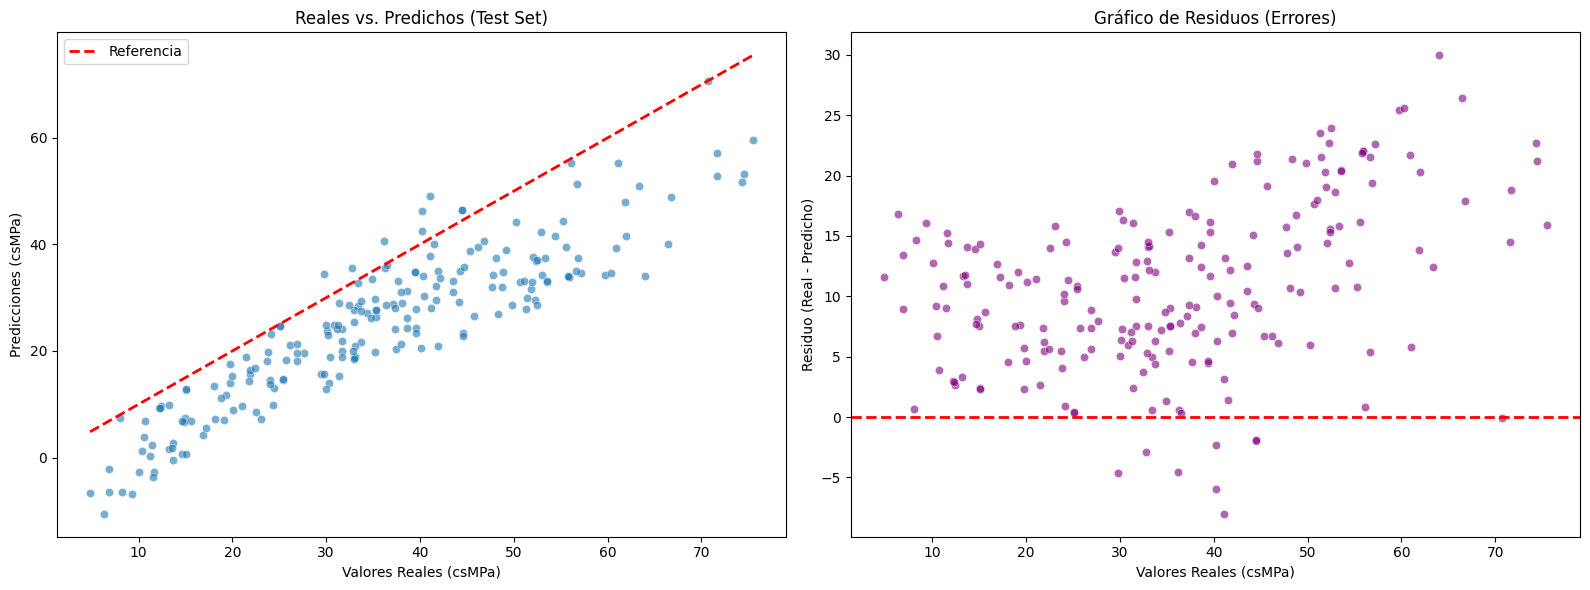

In [ ]:
from sklearn.linear_model import Ridge

# 1. Definir el Pipeline: Preprocesamiento + Modelo (Ridge para optimización)
pipeline_lr = Pipeline([
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('regressor', Ridge())
])

# 2. Configurar GridSearchCV para optimizar el hiperparámetro 'alpha'
param_grid = {'regressor__alpha': np.logspace(-3, 3, 13)}
grid_lr = GridSearchCV(pipeline_lr, param_grid, cv=5, scoring='neg_root_mean_squared_error')

# 3. Entrenar el modelo con búsqueda de hiperparámetros
grid_lr.fit(X_train, y_train)
best_model_lr = grid_lr.best_estimator_

# 4. Realizar predicciones para Train y Test
y_pred_train = best_model_lr.predict(X_train)
y_pred_test = best_model_lr.predict(X_test)

# 5. Calcular métricas para evaluar Overfitting
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Margen de seguridad
K = 1.55
y_pred_test_safe = y_pred_test - (K * rmse_test)

# Reevaluar metricas
mbe_test = np.mean(y_pred_test_safe - y_test)
r2_test = r2_score(y_test, y_pred_test_safe)
rmse_test_safe = np.sqrt(mean_squared_error(y_test, y_pred_test_safe))

# 6. Cálculo de Tasa de Riesgo por Sobreestimación (Predicho > Real)
overestimation_mask = y_pred_test_safe > y_test
risk_rate = (overestimation_mask.sum() / len(y_test)) * 100

print(f"--- Mejor Alpha Encontrado: {grid_lr.best_params_['regressor__alpha']:.4f} ---")
print("--- Evaluación de Overfitting: Ridge Regression (Optimizado) ---")
print(f"TRAIN - R2: {r2_train:.4f} | RMSE: {rmse_train:.4f}")
print(f"TEST  - R2: {r2_test:.4f}  | RMSE: {rmse_test_safe:.4f}")
print(f"MBE (Test): {mbe_test:.4f}")
print(f"Tasa de Riesgo por Sobreestimación: {risk_rate:.2f}%")

# 7. Gráficos de Evaluación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Valores Reales vs. Predichos
sns.scatterplot(x=y_test, y=y_pred_test_safe, alpha=0.6, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Referencia')
axes[0].set_title('Reales vs. Predichos (Test Set)')
axes[0].set_xlabel('Valores Reales (csMPa)')
axes[0].set_ylabel('Predicciones (csMPa)')
axes[0].legend()

# Gráfico B: Gráfico de Residuos
residuals = y_test - y_pred_test_safe
sns.scatterplot(x=y_test, y=residuals, alpha=0.6, color='purple', ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Gráfico de Residuos (Errores)')
axes[1].set_xlabel('Valores Reales (csMPa)')
axes[1].set_ylabel('Residuo (Real - Predicho)')

plt.tight_layout()
plt.show()

--- Mejor Parámetro: {'knn__n_neighbors': 4} ---
TRAIN - R2: 0.8469 | RMSE: 6.5948
TEST  - R2: 0.7121  | RMSE: 8.6134
MBE (Test): -0.7448
Tasa de Riesgo por Sobreestimación: 48.54%


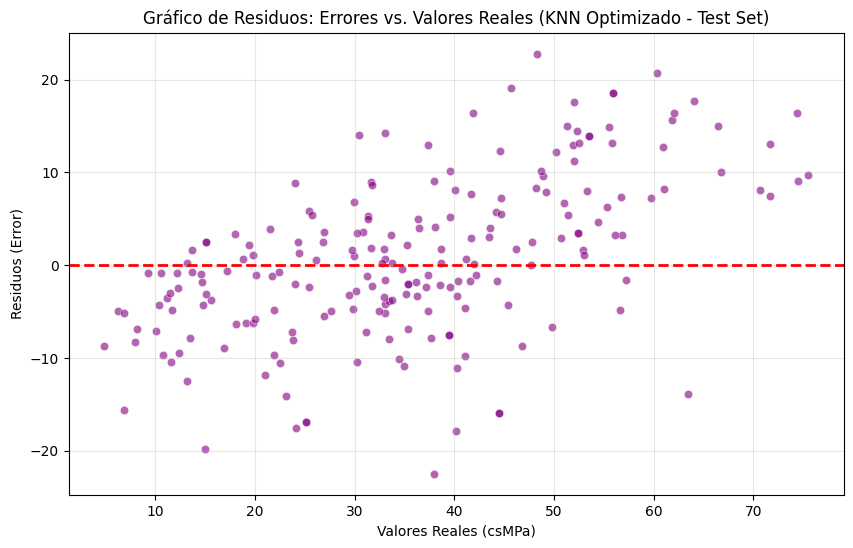

In [ ]:
# 1. Definir el Pipeline: Escalado + Modelo KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# 2. Configurar GridSearchCV
param_grid = {'knn__n_neighbors': range(3, 16)}
grid_knn = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# 3. Entrenar con GridSearch
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

# 4. Predicciones para Train y Test con el mejor modelo
y_pred_knn_train = best_knn.predict(X_train)
y_pred_knn_test = best_knn.predict(X_test)

# 5. Evaluación de Métricas
r2_knn_train = r2_score(y_train, y_pred_knn_train)
rmse_knn_train = np.sqrt(mean_squared_error(y_train, y_pred_knn_train))

r2_knn_test = r2_score(y_test, y_pred_knn_test)
rmse_knn_test = np.sqrt(mean_squared_error(y_test, y_pred_knn_test))
mbe_knn_test = np.mean(y_pred_knn_test - y_test)

# 5.1 Cálculo de Tasa de Riesgo por Sobreestimación (Predicho > Real)
overestimation_mask_knn = y_pred_knn_test > y_test
risk_rate_knn = (overestimation_mask_knn.sum() / len(y_test)) * 100

print(f"--- Mejor Parámetro: {grid_knn.best_params_} ---")
print(f"TRAIN - R2: {r2_knn_train:.4f} | RMSE: {rmse_knn_train:.4f}")
print(f"TEST  - R2: {r2_knn_test:.4f}  | RMSE: {rmse_knn_test:.4f}")
print(f"MBE (Test): {mbe_knn_test:.4f}")
print(f"Tasa de Riesgo por Sobreestimación: {risk_rate_knn:.2f}%")

# 6. Gráfico de Residuos (Set de Prueba)
residuos = y_test - y_pred_knn_test

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuos, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Gráfico de Residuos: Errores vs. Valores Reales (KNN Optimizado - Test Set)')
plt.xlabel('Valores Reales (csMPa)')
plt.ylabel('Residuos (Error)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Definir la malla de hiperparametros para Random Forest
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [8, 16, 32],
    'max_features': ['sqrt', 'log2', 0.5]
}

# 2. Configurar RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=SEED),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)

# 3. Entrenar y seleccionar el mejor modelo
rf_random.fit(X_train, y_train)
rf_model = rf_random.best_estimator_

# 4. Realizar predicciones para Train y Test
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

--- Mejor Configuraci3n: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 8} ---
--- Evaluacion de Overfitting: RandomForestRegressor (Optimizado con K Condicional) ---
TRAIN - R2: 0.9055 | RMSE: 5.1822
TEST  - R2: 0.4870  | RMSE: 11.4978
MBE (Test): -9.6223
Tasa de Riesgo por Sobreestimacion: 3.88%


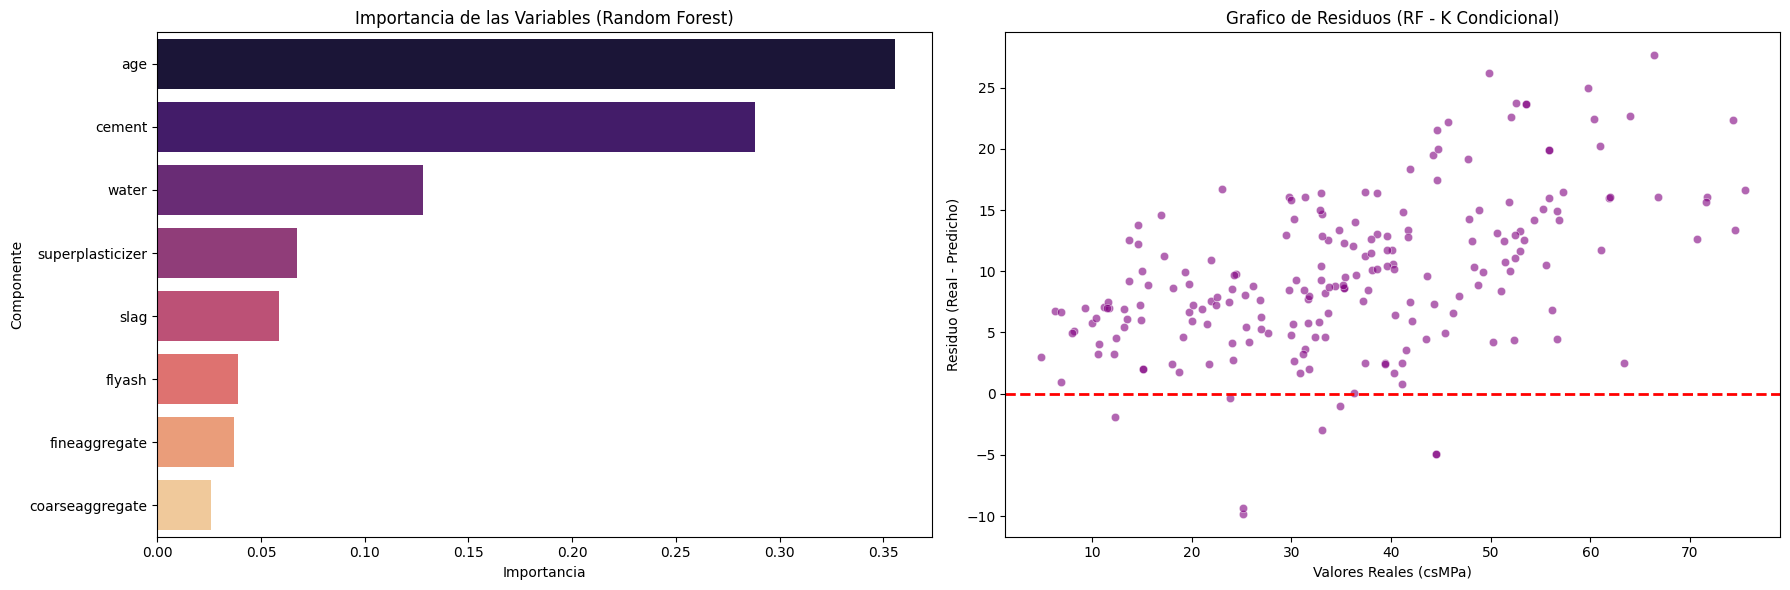

In [ ]:
# 5. Calcular metricas de evaluacion
r2_rf_train = r2_score(y_train, y_pred_rf_train)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))

rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))

# 5.1 Aplicamos margen de seguridad condicional
# K menor (1.1) para > 40 MPa, K mayor (1.6) para <= 40 MPa
K_condicional = np.where(y_pred_rf_test > 40, 1, 1.5)
y_pred_rf_test_safe = y_pred_rf_test - (K_condicional * rmse_rf_test)

rmse_rf_test_safe = np.sqrt(mean_squared_error(y_test, y_pred_rf_test_safe))
r2_rf_test = r2_score(y_test, y_pred_rf_test_safe)
mbe_rf_test = np.mean(y_pred_rf_test_safe - y_test)

# 5.2 Calculo de Riesgo de Sobreestimacion
overestimation_mask_rf = y_pred_rf_test_safe > y_test
risk_rate_rf = (overestimation_mask_rf.sum() / len(y_test)) * 100

print(f"--- Mejor Configuraci3n: {rf_random.best_params_} ---")
print("--- Evaluacion de Overfitting: RandomForestRegressor (Optimizado con K Condicional) ---")
print(f"TRAIN - R2: {r2_rf_train:.4f} | RMSE: {rmse_rf_train:.4f}")
print(f"TEST  - R2: {r2_rf_test:.4f}  | RMSE: {rmse_rf_test_safe:.4f}")
print(f"MBE (Test): {mbe_rf_test:.4f}")
print(f"Tasa de Riesgo por Sobreestimacion: {risk_rate_rf:.2f}%")

# 6. Extraer Feature Importance
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Componente': feature_names, 'Importancia': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# 7. Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafico A: Importancia de Variables
sns.barplot(data=feature_importance_df, x='Importancia', y='Componente', hue='Componente', palette='magma', ax=axes[0], legend=False)
axes[0].set_title('Importancia de las Variables (Random Forest)')

# Grafico B: Grafico de Residuos
residuos_rf = y_test - y_pred_rf_test_safe
sns.scatterplot(x=y_test, y=residuos_rf, alpha=0.6, color='purple', ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Grafico de Residuos (RF - K Condicional)')
axes[1].set_xlabel('Valores Reales (csMPa)')
axes[1].set_ylabel('Residuo (Real - Predicho)')

plt.tight_layout()
plt.show()

Optimizando XGBoost para mejorar el RMSE...
--- Mejor Configuración Encontrada: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.15, 'gamma': 0.2, 'colsample_bytree': 0.8} ---
TRAIN - R2: 0.9887 | RMSE: 1.7923
TEST  - R2: 0.7280  | RMSE: 4.2467
MBE (Test): -7.2287
Tasa de Riesgo por Sobreestimación: 2.43%

--- Detalle de Valores Sobreestimados (Riesgo Estructural) ---


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,water_cement_ratio,Real_csMPa,Predicho_Safe_csMPa,Exceso_csMPa
908,313.0,145.0,0.0,127.0,8.0,1000.0,822.0,28,0.405751,44.52,57.726250,13.206250
971,312.7,144.7,0.0,127.3,8.0,999.7,822.2,28,0.407099,44.52,57.012623,12.492623
919,313.0,0.0,0.0,178.0,8.0,1000.0,822.0,28,0.568690,25.10,29.243526,4.143526
982,312.7,0.0,0.0,178.1,8.0,999.7,822.2,28,0.569555,25.10,29.165657,4.065657
513,424.0,22.0,132.0,168.0,8.9,822.0,750.0,7,0.396226,40.29,41.155258,0.865258


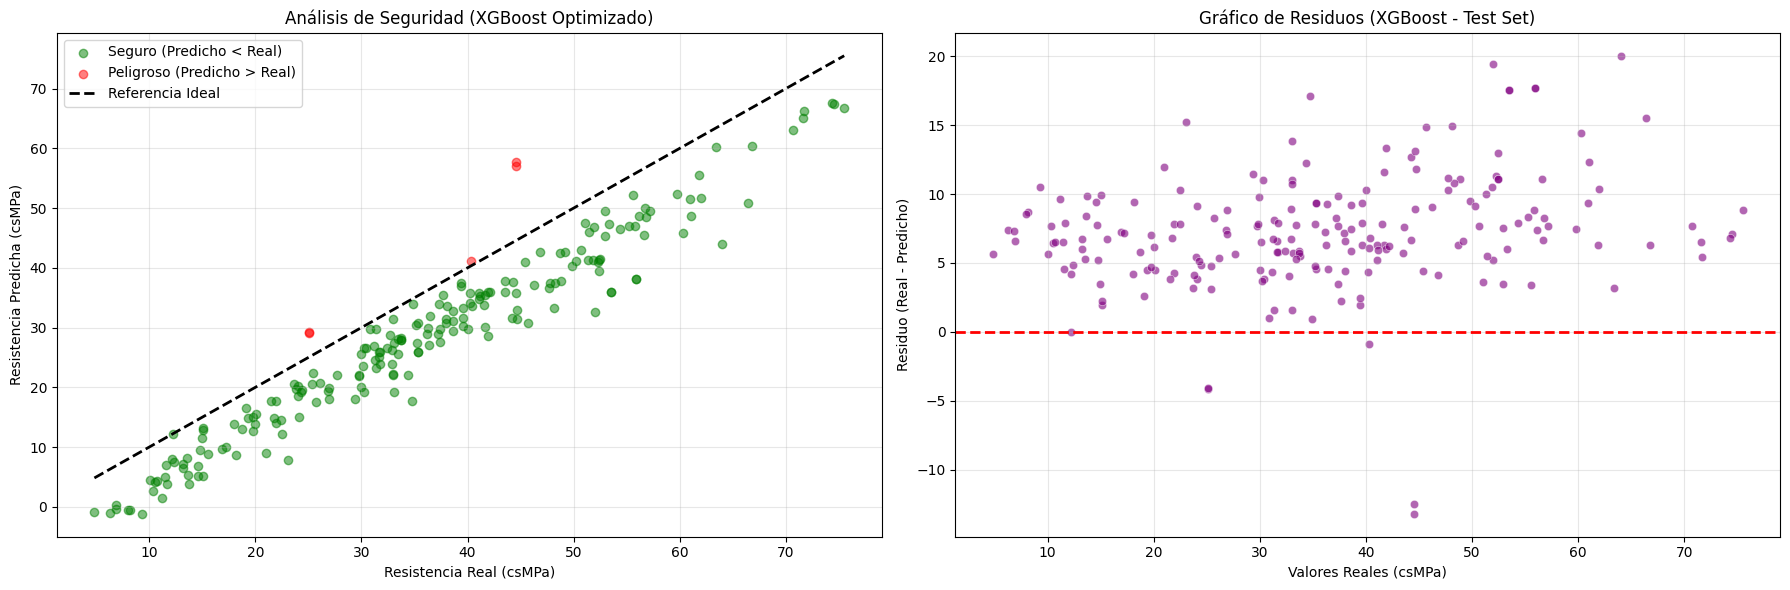

In [ ]:
# 1. Definir la malla de hiperparámetros para XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# 2. Configurar RandomizedSearchCV orientado a minimizar RMSE
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=SEED),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)

# 3. Entrenar y seleccionar el mejor modelo
print("Optimizando XGBoost para mejorar el RMSE...")
xgb_random.fit(X_train, y_train)
xgb_model = xgb_random.best_estimator_

# 4. Predicciones para Train y Test
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

# 5. Cálculo de métricas para evaluar Overfitting
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))

rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))

# Margen de seguridad
K = 1.6
y_pred_xgb_test_safe = y_pred_xgb_test - (K * rmse_xgb_test)

# Calculo con margen
rmse_xgb_test_safe = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test_safe))
r2_xgb_test = r2_score(y_test, y_pred_xgb_test_safe)
mbe_xgb_test = np.mean(y_pred_xgb_test_safe - y_test)

# 6. Cálculo de Tasa de Riesgo por Sobreestimación (Predicho > Real)
overestimation_mask = y_pred_xgb_test_safe > y_test
risk_rate = (overestimation_mask.sum() / len(y_test)) * 100

print(f"--- Mejor Configuración Encontrada: {xgb_random.best_params_} ---")
print(f"TRAIN - R2: {r2_xgb_train:.4f} | RMSE: {rmse_xgb_train:.4f}")
print(f"TEST  - R2: {r2_xgb_test:.4f}  | RMSE: {rmse_xgb_test:.4f}")
print(f"MBE (Test): {mbe_xgb_test:.4f}")
print(f"Tasa de Riesgo por Sobreestimación: {risk_rate:.2f}%")

# 7. Mostrar valores sobreestimados (Casos críticos)
print("\n--- Detalle de Valores Sobreestimados (Riesgo Estructural) ---")
overestimated_details = X_test[overestimation_mask].copy()
overestimated_details['Real_csMPa'] = y_test[overestimation_mask]
overestimated_details['Predicho_Safe_csMPa'] = y_pred_xgb_test_safe[overestimation_mask]
overestimated_details['Exceso_csMPa'] = overestimated_details['Predicho_Safe_csMPa'] - overestimated_details['Real_csMPa']
display(overestimated_details.sort_values(by='Exceso_csMPa', ascending=False))

# 8. Visualización de Seguridad y Residuos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico A: Seguridad Estructural (Reales vs Predichos)
axes[0].scatter(y_test[~overestimation_mask], y_pred_xgb_test_safe[~overestimation_mask], color='green', alpha=0.5, label='Seguro (Predicho < Real)')
axes[0].scatter(y_test[overestimation_mask], y_pred_xgb_test_safe[overestimation_mask], color='red', alpha=0.5, label='Peligroso (Predicho > Real)')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Referencia Ideal')
axes[0].set_title('Análisis de Seguridad (XGBoost Optimizado)')
axes[0].set_xlabel('Resistencia Real (csMPa)')
axes[0].set_ylabel('Resistencia Predicha (csMPa)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico B: Gráfico de Residuos
residuals_xgb = y_test - y_pred_xgb_test_safe
sns.scatterplot(x=y_test, y=residuals_xgb, alpha=0.6, color='purple', ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Gráfico de Residuos (XGBoost - Test Set)')
axes[1].set_xlabel('Valores Reales (csMPa)')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()